<a href="https://colab.research.google.com/github/KarabiMandal185/Application-of-Data-Mining/blob/main/ADM(Outlier_Detection_)20_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
np.random.seed
data= np.random.normal(0,1,100)
outliers = np.random.uniform(5,10,5)

In [6]:
data_with_outliers = np.concatenate([data, outliers])

In [7]:
df =  pd.DataFrame(data_with_outliers, columns=['value'])

In [9]:
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR= Q3-Q1
lower_bound = Q1 - 1.5*IQR
lower_bound = Q1 + 1.5*IQR

In [12]:
outliers_iqr = df[(df['value'] < lower_bound) | (df['value'] > upper_bound)]

In [13]:
z_scores = stats.zscore(df['value'])
outliers_zscore = df[np.abs(z_scores) >3 ]

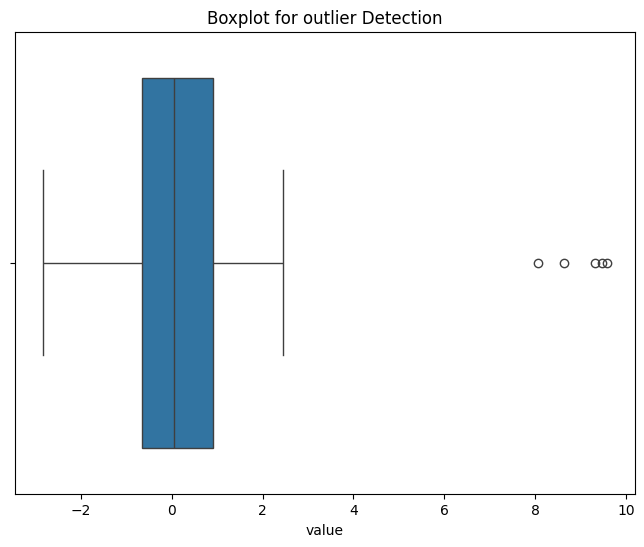

In [14]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['value'])
plt.title("Boxplot for outlier Detection")
plt.show()


In [15]:
df_capped = df.copy()
df_capped['value'] = np.clip(df_capped['value'], lower_bound, upper_bound)



In [17]:
df_removed = df.copy()



In [20]:

df_removed = df_removed[(df_removed['value'] >= lower_bound) & (df_removed['value'] <= upper_bound)]

In [23]:
df_imputed = df.copy()
median_value = df['value'].median()
df_imputed['value'] = np.where((df_imputed['value'] < lower_bound) | (df_imputed['value'] > upper_bound), median_value, df_imputed['value'])


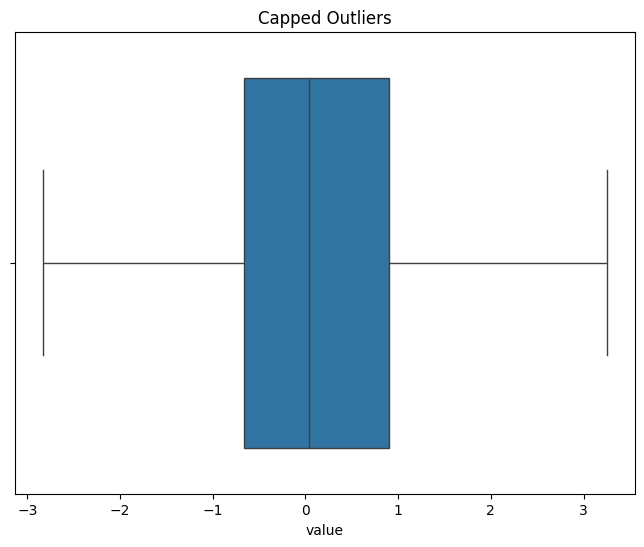

In [25]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_capped['value'])
plt.title("Capped Outliers")
plt.show()

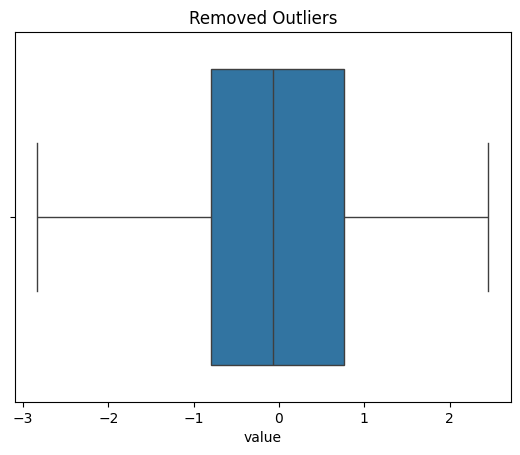

In [27]:
sns.boxplot(x=df_removed['value'])
plt.title("Removed Outliers")
plt.show()

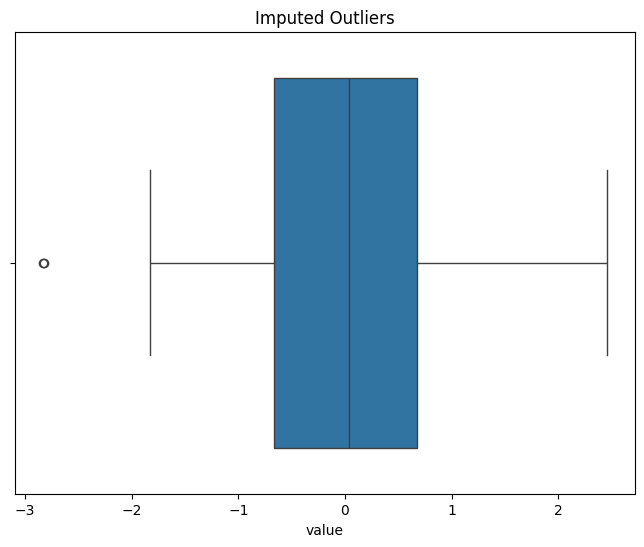

In [29]:

plt.figure(figsize=(8, 6))
sns.boxplot(x=df_imputed['value'])
plt.title("Imputed Outliers")
plt.show()

In [30]:
print(f"Outliers detected using IQR:\n{outliers_iqr}")
print(f"Outliers detected using Z-Score:\n{outliers_zscore}")

Outliers detected using IQR:
        value
100  8.638553
101  9.314121
102  9.574757
103  8.067692
104  9.467904
Outliers detected using Z-Score:
        value
100  8.638553
101  9.314121
102  9.574757
103  8.067692
104  9.467904
